**This notebook presents a simple example of the `umbra` transit search code version 0.7.1, but we recommend waiting for `umbra` 1.0.0.**

In [1]:
import numpy as np

import umbra
import batman
from transitleastsquares import grid

%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
RNG = np.random.default_rng(5627323756)
MIN_IN_DAY = 24 * 60

We start by defining observational parameters and setting up a hot Jupiter type system for the batman transit model.

In [3]:
# Observational parameters.
baseline = 90  # The star was observed for 90 days.
exp_time = 3./MIN_IN_DAY  # We took 3 minute exposures...
exp_cadence = 5./MIN_IN_DAY  # ...and an exposure every 5 minutes
start_time = 100. # Observations started at day 100.
white_noise = 500e-6  # White noise had a standard deviation of 500 ppm.

# Transit parameters.
ld_type = 'linear'
ld_pars = [0.6,]

period = 5.876
impact = 0.3

# Compute the scaled semi-major axis and the inclination.
sma = umbra.density2axis(1.41, period)  # Assume solar density.
inc = umbra.impact2inc(impact, sma, 0., 90.)

# Intialize the TransitParams object.
params = batman.TransitParams()
params.t0 = 3.
params.per = period
params.rp = 0.02
params.a = sma
params.inc = inc
params.ecc = 0.                     
params.w = 90.                        
params.limb_dark = ld_type
params.u = ld_pars

Next we generate a lightcurve with the transit and white noise.

In [4]:
# Generate the observation times.
npoints = int(baseline / exp_cadence)  # 5 minute cadence
time = start_time + exp_cadence * np.arange(npoints)

# Evaluate the transit model.
m = batman.TransitModel(params, time, exp_time=exp_time, supersample_factor=9)
transit = m.light_curve(params)

# Generate the white noise.
noise = RNG.normal(loc=0, scale=white_noise, size=npoints)

# Compute the final flux and corresponding error values.
flux = transit + noise
flux_err = white_noise * np.ones_like(flux)

Let's inspect the lightcurve.

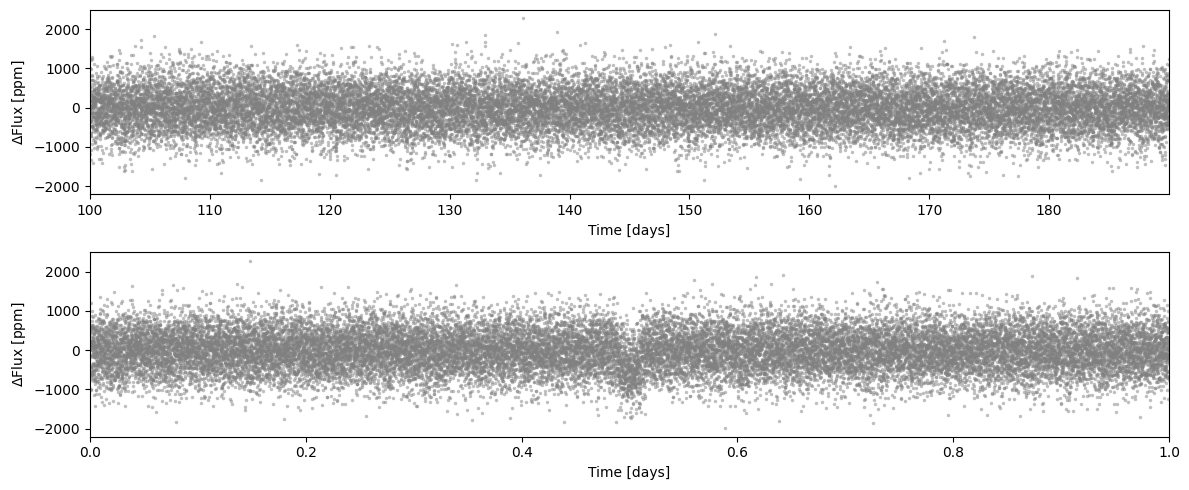

In [5]:
# Compute the folded-phase, centering the transit at phase=0.5.
phase = (time - params.t0) / params.per
phase = np.mod(phase + 0.5, 1)

# Plot the lightcurve as a function of time and phase.
plt.figure(figsize=(12, 5))

ax = plt.subplot(211)

plt.plot(time, 1e6 * (flux - 1), '.', markersize=5, markeredgecolor='None', alpha=0.5, color='gray')
plt.xlim(time[0], time[-1])

plt.xlabel('Time [days]')
plt.ylabel(r'$\Delta$Flux [ppm]')

plt.subplot(212, sharey=ax)

plt.plot(phase, 1e6 * (flux - 1), '.', markersize=5, markeredgecolor='None', alpha=0.5, color='gray')
plt.xlim(0, 1)

plt.xlabel('Time [days]')
plt.ylabel(r'$\Delta$Flux [ppm]')

plt.tight_layout()

Now we need the period grid to be searched, we assume solar mass and radius and generate it using the `transitleastsquares` package

In [6]:
periods = grid.period_grid(1.0, 1.0, np.ptp(time))

We're now ready to perform the transit search. For this example we use TLS templates, and use the 'umbra' normalisation of the periodogram power.

In [7]:
search_result = umbra.transit_search(
    time,  # The lightcurve.
    flux,
    flux_err,
    periods,  # The period grid.
    exp_time,  # The observational parameters.
    exp_cadence,
    R_star_min = 0.8,  # A range of stellar parameters around the true solar values.
    R_star_max = 1.2,
    M_star_min = 0.8,
    M_star_max = 1.2,
    ld_type=ld_type,  # We use the true limb-darkening for this example search.
    ld_pars=ld_pars,
    search_mode='TLS',  # Use transit-shaped templates in the search. 
    normalisation='umbra',  # Use the 'umbra' normalisation for the periodogram power.
    oversampling_duration=3,  # Set the duration sampling.
    max_duty_cycle=0.15,  # This parameter controls the internal grouping of periods in the search, 0.15 is a good value.
)

Finally we plot the search result. In the top panel we show the periodogram power which is defined to be normalised between 0 and 1. The middle panel shows the $\Delta\chi^2_{-}$ and $\Delta\chi^2_{+}$ corresponding to the peak power. The $\Delta\chi^2_{-}$ is the best-fit improvement corresponding to the peak power. The $\Delta\chi^2_{+}$ corresponds to the best-fit unphysical (i.e. corresponding to a brightening) transit model at the same period and duration as the peak power. Finally the bottom panel shows the lightcurve phase-folded to the recovered period and epoch, together with the transit template used in the detection.

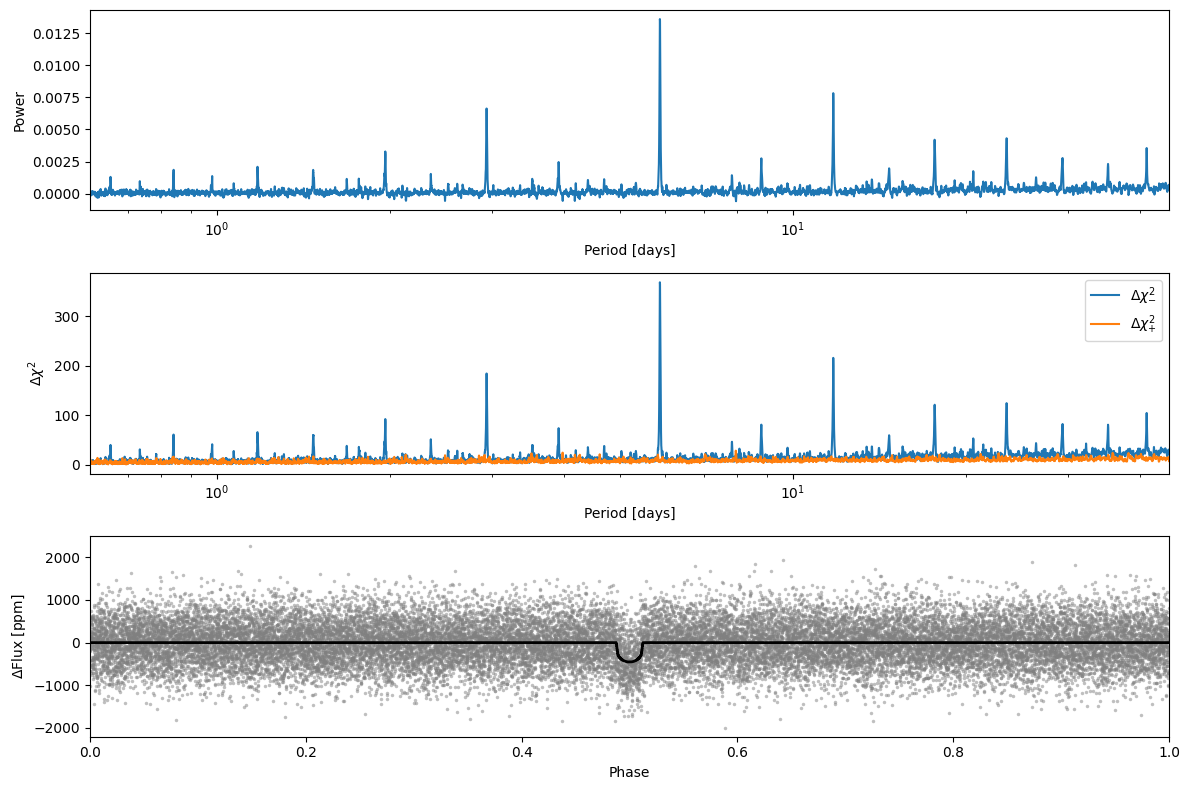

In [8]:
plt.figure(figsize=(12, 8))
    
ax = plt.subplot(311)

plt.semilogx(search_result.periods, search_result.power)

plt.xlim(search_result.periods[0], search_result.periods[-1])

plt.xlabel('Period [days]')
plt.ylabel('Power')

plt.subplot(312, sharex=ax)

plt.semilogx(search_result.periods, search_result.dchisq_dec, label=r'$\Delta\chi^2_{-}$')
plt.semilogx(search_result.periods, search_result.dchisq_inc, label=r'$\Delta\chi^2_{+}$')

plt.legend()
plt.xlabel('Period [days]')
plt.ylabel(r'$\Delta\chi^2$')

plt.subplot(313)

sort = np.argsort(search_result.model_phase)
plt.plot(search_result.model_phase, 1e6 * (flux - 1), '.', markersize=5, markeredgecolor='None', alpha=0.5, color='gray')
plt.plot(search_result.model_phase[sort], 1e6 * (search_result.model_flux[sort] - 1), lw=2, color='k')

plt.xlim(0, 1)

plt.xlabel('Phase')
plt.ylabel(r'$\Delta$Flux [ppm]')

plt.tight_layout()